This is the code for SkewT plotting in a Jupyter notebook.

#####
2025/12/11
#####



In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd

from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units

from datetime import datetime

from siphon.simplewebservice.wyoming import WyomingUpperAir

data_list = []

for days in range(1,2):
    data00 = datetime(2024, 1, days, 0)
    data12 = datetime(2024, 1, days, 12) 
    data_list.append(data00)
    data_list.append(data12)

station = '89009'
for date in data_list:
    try:
        df = WyomingUpperAir.request_data(date, station)
    except:
        print(f'No data for {station} on {date}')
        continue

    #print(df.head())

    h = df['height'].values
    p = df['pressure'].values
    T = df['temperature'].values
    Td = df['dewpoint'].values
    u = df['u_wind'].values
    v = df['v_wind'].values

    print(type(T), T[1])

    # # make figure and `SkewT` object
    # fig = plt.figure(figsize=(9, 9))
    # skewt = SkewT(fig=fig, rotation=45)

    # # plot sounding data
    # skewt.plot(p, T, 'r', label='Air Temperature')  # air temperature
    # skewt.plot(p, Td, 'b', label='Dew Point')  # dew point
    # skewt.plot_barbs(p[p >= 100], u[p >= 100], v[p >= 100])  # wind barbs
    # skewt.ax.legend(loc='best')

    # plt.title(f'Skew-T \n South Pole {date.strftime("%Y-%m-%d %H:%M UTC")}', fontsize=16)
    # fig.savefig(f'fig/skewt_South Pole_{date.strftime("%Y-%m-%d_%H-%M_UTC")}.png', dpi=300)
    # plt.close(fig)

# make figure and `SkewT` object
fig2 = plt.figure(figsize=(9, 9))
skewt2 = SkewT(fig=fig2, rotation=45)

# plot sounding data
skewt2.plot(p, T, 'r', label='Air Temperature') # air temperature
skewt2.plot(p, Td, 'b', label='Dew Point') # dew point

skewt2.ax.set_title('Skew-T \n South Pole', fontsize=16)
skewt2.ax.set_xlabel('Temperature (°C)')
skewt2.ax.set_ylabel('Pressure (hPa)')
skewt2.plot_barbs(p[p >= 100], u[p >= 100], v[p >= 100])  # wind barbs

# add dry adiabats, moist adiabats, and mixing ratio lines
skewt2.plot_dry_adiabats(label='Dry Adiabats')
skewt2.plot_moist_adiabats(label='Moist Adiabats')
skewt2.plot_mixing_lines(label='Mixing Ratio')
skewt2.ax.legend(loc='best')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from metpy.plots import SkewT
import glob

Per_list = []
Tem_list = []
vmr_list = []

amc_list = glob.glob('*.dat.amc')

data_list = []

for days in range(1,2):
    # data00 = datetime(2024, 1, days, 0)
    data12 = datetime(2024, 1, days, 12) 
    # data_list.append(data00)
    data_list.append(data12)

station = '89009'

#compare with balloon data around 12:00 UTC WVR data around 11:50 and 13:05 
# (the one before 12:00 UTC is the one after 12:00 UTC)


for date in data_list:
    try:
        df = WyomingUpperAir.request_data(date, station)
    except:
        print(f'No data for {station} on {date}')
        continue

    #print(df.head())

    h = df['height'].values
    p = df['pressure'].values
    T = df['temperature'].values
    Td = df['dewpoint'].values
    u = df['u_wind'].values
    v = df['v_wind'].values

for file_n in amc_list:

    with open(file_n, 'r') as file:

        getTime = file_n.split('S')[0]+file_n.split('S')[1].split('.')[0]
        date = datetime.strptime(getTime, '%Y%m%d%H%M%S')
        print(date)

        lines = file.readlines()
        for line in lines:
            if '# P' in line:
                Per = float(line.split(' ')[2].strip()) #mbar=hPa
                Per_list.append(Per)
            elif '# T' in line:
                Tem = float(line.split(' ')[2].strip()) #K
                Tem_list.append(Tem)    
            elif 'column h2o hydrostatic' in line and '(* ' not in line:
                vmr = float(line.split(' ')[3].strip()) #g/g
                vmr_list.append(vmr)
            elif 'column h2o hydrostatic' in line and '(* ' in line:
                vmr_0 = float(line.split(' ')[3].strip()) #g/g
                vmr = vmr_0 * float(line.split(')  (* ')[1].strip().split(')')[0])
                #print(vmr_0, vmr)
                vmr_list.append(vmr)


WVPP = [v * p for v, p in zip(vmr_list, Per_list)] # Water Vapor Partial Pressure (hPa)
Tem_C = [t - 273.15 for t in Tem_list] # Temperature (°C)
SVP = [6.112*np.exp((17.67 * np.array(T)) / (T + 243.5)) for T in Tem_C] # Saturation Vapor Pressure (hPa)

RH = [WVPP[i] / SVP[i] * 100 for i in range(len(WVPP))]

b_cons = 17.625
c_cons = 243.04

gamma = [np.log(RH[i] / 100) + (b_cons*Tem_C[i]) / (Tem_C[i] + c_cons)  for i in range(len(RH))]
T_dry = [(c_cons*gamma[i]) / (b_cons - gamma[i]) for i in range(len(gamma))] # Dew Point Temperature (°C)

T_dry = np.array(T_dry)
Per = np.array(Per_list)
Tem_C = np.array(Tem_C)

fig = plt.figure(figsize=(9, 9))
skewt2 = SkewT(fig=fig, rotation=45)



# plot sounding data
skewt2.plot(Per, Tem_C, 'r', label='am Air Temperature') # air temperature
skewt2.plot(Per, T_dry, 'b', label='am Dew Point') # dew point
skewt2.plot(p, T, 'g', ls = '--', label='Balloon  Air Temperature') # air temperature
skewt2.plot(p, Td, 'y', ls = '--', label='Balloon Dew Point') # dew point

skewt2.ax.set_title('Skew-T \n South Pole', fontsize=16)
skewt2.ax.set_xlabel('Temperature (°C)')
skewt2.ax.set_ylabel('Pressure (hPa)')

skewt2.ax.legend(loc='best')


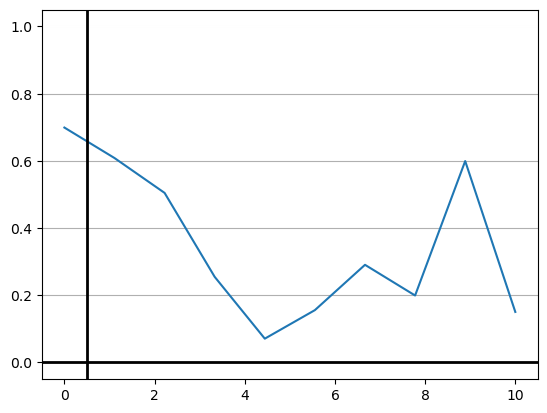

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 10)
y = np.random.rand(10)

fig, ax = plt.subplots()
ax.plot(x, y)

# black grid
ax.grid(True, axis='x', color='black', linewidth=1)

# white grid (overlay)
ax.grid(True, axis='x', color='white', linewidth=0.5)
plt.axhline(0, color='black', linewidth=2)
plt.axhline(1, color='white', linewidth=2)
plt.axvline(0.5, color='black', linewidth=2)

plt.grid()
plt.show()
